In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)


## Load rMATS data and filter for significance

In [ ]:
# Need to be able to run this for any cell line

In [2]:
# Load in rMATS skipped exon v29 files for SAFB
# SAFB_HepG2 = pl.read_csv('/project/PlatigLab/data/ENCORE2026/rMATS_analysis/v29_rMATS_RBPKD/SAFB-CRISPR-HepG2/SE.MATS.JC.txt', separator='\t')
SAFB_K562 = pl.read_csv('/project/PlatigLab/data/ENCORE2026/rMATS_analysis/v29_rMATS_RBPKD/SAFB-CRISPR-K562/SE.MATS.JC.txt', separator='\t')

In [3]:
# Drop unnecessary columns from the rMATS data and remove non-significant events

# SAFB_HepG2_filtered = SAFB_HepG2[["FDR", "geneSymbol", "strand", "chr", "exonStart_0base", "exonEnd", "upstreamES", "upstreamEE", "downstreamES", "downstreamEE", "ID", "IncFormLen", "SkipFormLen", "PValue", "IncLevelDifference"]]

SAFB_K562_unfiltered = SAFB_K562[["FDR", "geneSymbol", "strand", "chr", "exonStart_0base", "exonEnd", "upstreamES", "upstreamEE", "downstreamES", "downstreamEE", "ID", "IncFormLen", "SkipFormLen", "PValue", "IncLevelDifference"]]

In [4]:
print(SAFB_K562_unfiltered.shape)

(46029, 15)


In [31]:
print(SAFB_K562_unfiltered.unique(
    subset=["exonStart_0base", "exonEnd", "upstreamES", "upstreamEE", "downstreamES", "downstreamEE"]
).select(["exonStart_0base", "exonEnd", "upstreamES", "upstreamEE", "downstreamES", "downstreamEE"]))

shape: (46_029, 6)
┌─────────────────┬───────────┬────────────┬────────────┬──────────────┬──────────────┐
│ exonStart_0base ┆ exonEnd   ┆ upstreamES ┆ upstreamEE ┆ downstreamES ┆ downstreamEE │
│ ---             ┆ ---       ┆ ---        ┆ ---        ┆ ---          ┆ ---          │
│ i64             ┆ i64       ┆ i64        ┆ i64        ┆ i64          ┆ i64          │
╞═════════════════╪═══════════╪════════════╪════════════╪══════════════╪══════════════╡
│ 122850423       ┆ 122850520 ┆ 122849095  ┆ 122849439  ┆ 122855644    ┆ 122855786    │
│ 125110643       ┆ 125110746 ┆ 125110490  ┆ 125110549  ┆ 125111538    ┆ 125111579    │
│ 24804704        ┆ 24804851  ┆ 24804176   ┆ 24804319   ┆ 24805013     ┆ 24805151     │
│ 657162          ┆ 657250    ┆ 637700     ┆ 637861     ┆ 693018       ┆ 693111       │
│ 4062212         ┆ 4062299   ┆ 4060412    ┆ 4061147    ┆ 4062556      ┆ 4062633      │
│ 241653511       ┆ 241653610 ┆ 241651009  ┆ 241651335  ┆ 241654545    ┆ 241654647    │
│ 175113993  

In [5]:
# SAFB_HepG2_filtered = SAFB_HepG2_filtered.filter(
#    (pl.col("FDR") <= 0.1) &
#    (pl.col("IncLevelDifference").abs() >= 0.05)
#)

SAFB_K562_filtered = SAFB_K562_unfiltered.filter(
    (pl.col("FDR") <= 0.1) &
    (pl.col("IncLevelDifference").abs() >= 0.05)
)

In [6]:
print(SAFB_K562_filtered.shape)

(2004, 15)


In [38]:
safb_rmats_filtered = SAFB_K562_filtered.write_csv("safb_rmats_filtered.csv")

Read in BAT and print columns

In [39]:
safb_rmats_unfiltered = SAFB_K562_unfiltered.write_csv("safb_rmats_unfiltered.csv")

In [7]:
# Function to get path for big table

from pathlib import Path

def get_path(cell_line: str, path_file: str = "data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

In [ ]:
# Read in data for both cell lines

# data_path_HepG2 = get_path("HepG2")
# BAT_HepG2 = pl.read_ipc(data_path_HepG2)

In [8]:
data_path_K562 = get_path("K562")
BAT_K562 = pl.read_ipc(data_path_K562)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [9]:
print(BAT_K562.shape)

(6291182, 1700)


## Matching events

In [ ]:
# Create a new df from the rMATS data that contains the event ID and a string of the values to match on

In [10]:
SAFB_events_K562 = SAFB_K562_filtered.select([
    pl.col("ID"),
    pl.when(pl.col("strand") == "+")
    .then(
        pl.concat_str([
            pl.col("chr"),
            pl.col("strand"),
            pl.col("upstreamES"),
            pl.col("upstreamEE"),
            pl.col("exonStart_0base"),
            pl.col("exonEnd"),
            pl.col("downstreamES"),
            pl.col("downstreamEE")
        ], separator="_")
    )
    .otherwise(
        pl.concat_str([
            pl.col("chr"),
            pl.col("strand"),
            pl.col("downstreamEE"),
            pl.col("downstreamES"),
            pl.col("exonEnd"),
            pl.col("exonStart_0base"),
            pl.col("upstreamEE"),
            pl.col("upstreamES")
        ], separator="_")
    )
    .alias("string")
])

In [11]:
SAFB_nonsig_events_K562 = SAFB_K562_unfiltered.select([
    pl.col("ID"),
    pl.when(pl.col("strand") == "+")
    .then(
        pl.concat_str([
            pl.col("chr"),
            pl.col("strand"),
            pl.col("upstreamES"),
            pl.col("upstreamEE"),
            pl.col("exonStart_0base"),
            pl.col("exonEnd"),
            pl.col("downstreamES"),
            pl.col("downstreamEE")
        ], separator="_")
    )
    .otherwise(
        pl.concat_str([
            pl.col("chr"),
            pl.col("strand"),
            pl.col("downstreamEE"),
            pl.col("downstreamES"),
            pl.col("exonEnd"),
            pl.col("exonStart_0base"),
            pl.col("upstreamEE"),
            pl.col("upstreamES")
        ], separator="_")
    )
    .alias("string")
])

In [12]:
# Extract the first 8 sections from the index column
BAT_K562_extracted = BAT_K562.with_columns(
    pl.col("index")
    .str.extract(r"^((?:[^_]*_){7}[^_]*)")
    .alias("string")
)

In [13]:
# Join on the string column; filtered
SAFB_K562_KD_matches_BAT = BAT_K562_extracted.join(
    SAFB_events_K562.select("string"),
    on="string",
     how="inner"
).drop("string")

In [14]:
# Join on the string column; nonsig
SAFB_nonsig_K562_KD_matches_BAT = BAT_K562_extracted.join(
    SAFB_nonsig_events_K562.select("string"),
    on="string",
     how="inner"
).drop("string")

In [15]:
# This is the BAT with only events present in the SAFB KD data
print(SAFB_K562_KD_matches_BAT.shape)

(153081, 1700)


In [30]:
# This is the BAT with only events present in the SAFB KD data
print(SAFB_K562_KD_matches_BAT.shape)
print(SAFB_K562_KD_matches_BAT.unique(
    subset=["Upstream Exon", "Downstream Exon", "Main Exon"]
).select(["Upstream Exon", "Downstream Exon", "Main Exon"]))

(153081, 1700)
shape: (1_034, 3)
┌─────────────────┬─────────────────┬─────────────────┐
│ Upstream Exon   ┆ Downstream Exon ┆ Main Exon       │
│ ---             ┆ ---             ┆ ---             │
│ str             ┆ str             ┆ str             │
╞═════════════════╪═════════════════╪═════════════════╡
│ ENSE00003693915 ┆ ENSE00003499427 ┆ ENSE00003549777 │
│ ENSE00001210644 ┆ ENSE00001210635 ┆ ENSE00001210640 │
│ ENSE00002024295 ┆ ENSE00002038704 ┆ ENSE00003652425 │
│ ENSE00003585790 ┆ ENSE00003699418 ┆ ENSE00003695607 │
│ ENSE00003648846 ┆ ENSE00001088370 ┆ ENSE00001088371 │
│ ENSE00001663327 ┆ ENSE00001797527 ┆ ENSE00001613992 │
│ ENSE00002247416 ┆ ENSE00002243525 ┆ ENSE00003467943 │
│ ENSE00002618051 ┆ ENSE00003465954 ┆ ENSE00003611261 │
│ ENSE00003602787 ┆ ENSE00003496766 ┆ ENSE00003617211 │
│ ENSE00001928567 ┆ ENSE00003664122 ┆ ENSE00001916118 │
│ ENSE00001169933 ┆ ENSE00001013007 ┆ ENSE00000764432 │
│ ENSE00001098440 ┆ ENSE00001098423 ┆ ENSE00001098428 │
│ ENSE000017063

In [29]:
print(SAFB_nonsig_K562_KD_matches_BAT.unique(
    subset=["Upstream Exon", "Downstream Exon", "Main Exon"]
).select(["Upstream Exon", "Downstream Exon", "Main Exon"]))

shape: (28_030, 3)
┌─────────────────┬─────────────────┬─────────────────┐
│ Upstream Exon   ┆ Downstream Exon ┆ Main Exon       │
│ ---             ┆ ---             ┆ ---             │
│ str             ┆ str             ┆ str             │
╞═════════════════╪═════════════════╪═════════════════╡
│ ENSE00003492829 ┆ ENSE00003616905 ┆ ENSE00001942305 │
│ ENSE00001088329 ┆ ENSE00002372694 ┆ ENSE00001088326 │
│ ENSE00002465970 ┆ ENSE00003520396 ┆ ENSE00001603631 │
│ ENSE00003724475 ┆ ENSE00003719955 ┆ ENSE00003754537 │
│ ENSE00002595962 ┆ ENSE00003535274 ┆ ENSE00003533151 │
│ ENSE00003602880 ┆ ENSE00003610340 ┆ ENSE00003504359 │
│ ENSE00003633383 ┆ ENSE00001681606 ┆ ENSE00001729648 │
│ ENSE00003697472 ┆ ENSE00003734410 ┆ ENSE00003733619 │
│ ENSE00002048612 ┆ ENSE00002063368 ┆ ENSE00003718011 │
│ ENSE00003481491 ┆ ENSE00003672319 ┆ ENSE00003549110 │
│ ENSE00002046410 ┆ ENSE00002046001 ┆ ENSE00003528569 │
│ ENSE00000848139 ┆ ENSE00000848136 ┆ ENSE00000848138 │
│ ENSE00001396791 ┆ ENSE00003

## QC checks

In [ ]:
# Get events from the BAT that match SAFB KD events and return those with SAFB binding at pos 3

In [17]:
SAFB_sig = SAFB_K562_KD_matches_BAT.filter(pl.col("SAFB_3_binding") == 1)

In [18]:
SAFB_nonsig = SAFB_nonsig_K562_KD_matches_BAT.filter(pl.col("SAFB_3_binding") == 1)

In [19]:
print(SAFB_sig.shape)

(0, 1700)


In [20]:
print(SAFB_nonsig.shape)

(1357, 1700)


In [21]:
# Filter for rows where SAFB is bound
binding_cols = ["SAFB_1_binding", "SAFB_2_binding", "SAFB_3_binding", 
                "SAFB_4_binding", "SAFB_5_binding", "SAFB_6_binding"]

SAFB_bound_K562 = SAFB_K562_KD_matches_BAT.filter(
    pl.any_horizontal([pl.col(c) == 1 for c in binding_cols])
)

In [22]:
# Filter for rows where SAFB is bound
binding_cols = ["SAFB_1_binding", "SAFB_2_binding", "SAFB_3_binding", 
                "SAFB_4_binding", "SAFB_5_binding", "SAFB_6_binding"]

SAFB_nonsig_bound_K562 = SAFB_nonsig_K562_KD_matches_BAT.filter(
    pl.any_horizontal([pl.col(c) == 1 for c in binding_cols])
)

In [23]:
print(SAFB_bound_K562.shape)

(482, 1700)


In [25]:
df = SAFB_bound_K562.drop([col for col in SAFB_bound_K562.columns if 'shap' in col])
df.write_csv("check_event.csv")

In [24]:
print(SAFB_nonsig_bound_K562.shape)

(2867, 1700)


In [27]:
# Filter for rows where SAFB is bound
binding_cols = ["SAFB_1_binding", "SAFB_2_binding", "SAFB_3_binding", 
                "SAFB_4_binding", "SAFB_5_binding", "SAFB_6_binding"]

for col in binding_cols: 
    print(SAFB_K562_KD_matches_BAT.filter(
        pl.col(col) ==1
    ).unique(
          subset=["Upstream Exon", "Downstream Exon", "Main Exon"]
    ).height)

0
0
0
0
0
2


In [28]:
for col in binding_cols:
    result = SAFB_K562_KD_matches_BAT.filter(
        pl.col(col) == 1
    ).unique(
        subset=["Upstream Exon", "Downstream Exon", "Main Exon"]
    )
    print(f"\n{col}: {result.height} rows")
    print(result.select(["Upstream Exon", "Downstream Exon", "Main Exon"]))


SAFB_1_binding: 0 rows
shape: (0, 3)
┌───────────────┬─────────────────┬───────────┐
│ Upstream Exon ┆ Downstream Exon ┆ Main Exon │
│ ---           ┆ ---             ┆ ---       │
│ str           ┆ str             ┆ str       │
╞═══════════════╪═════════════════╪═══════════╡
└───────────────┴─────────────────┴───────────┘

SAFB_2_binding: 0 rows
shape: (0, 3)
┌───────────────┬─────────────────┬───────────┐
│ Upstream Exon ┆ Downstream Exon ┆ Main Exon │
│ ---           ┆ ---             ┆ ---       │
│ str           ┆ str             ┆ str       │
╞═══════════════╪═════════════════╪═══════════╡
└───────────────┴─────────────────┴───────────┘

SAFB_3_binding: 0 rows
shape: (0, 3)
┌───────────────┬─────────────────┬───────────┐
│ Upstream Exon ┆ Downstream Exon ┆ Main Exon │
│ ---           ┆ ---             ┆ ---       │
│ str           ┆ str             ┆ str       │
╞═══════════════╪═════════════════╪═══════════╡
└───────────────┴─────────────────┴───────────┘

SAFB_4_binding: 0 row

In [26]:
# Filter for rows where SAFB is bound
binding_cols = ["SAFB_1_binding", "SAFB_2_binding", "SAFB_3_binding", 
                "SAFB_4_binding", "SAFB_5_binding", "SAFB_6_binding"]

for col in binding_cols: 
    print(SAFB_nonsig_K562_KD_matches_BAT.filter(
        pl.col(col) ==1
    ).unique(
          subset=["Upstream Exon", "Downstream Exon", "Main Exon"]
    ).height)

1
2
6
3
2
4


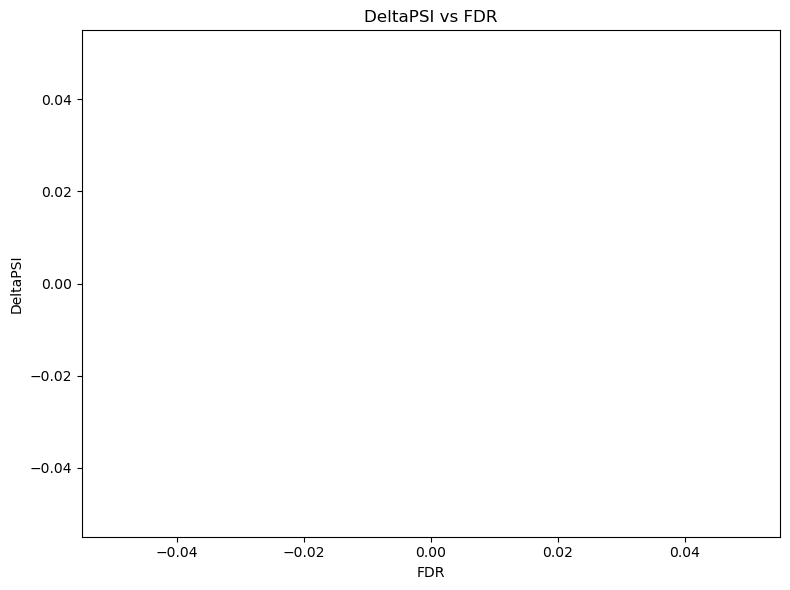

In [23]:
# Trying to figure out why the events at 3 are sig here but not showing up in th edf

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(SAFB_sig['FDR'], SAFB_sig['DeltaPSI'].abs(), alpha=0.2, edgecolors='k', linewidths=0.5, color='skyblue')

plt.xlabel('FDR')
plt.ylabel('DeltaPSI')
plt.title('DeltaPSI vs FDR')

plt.tight_layout()
plt.show()

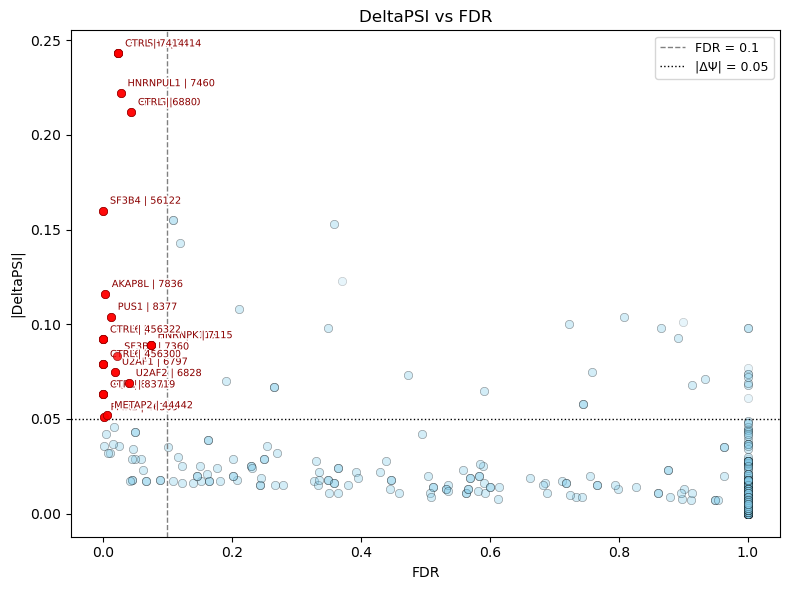

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(8, 6))

# Define significance thresholds
fdr_thresh = 0.1
dpsi_thresh = 0.05

# Split into significant and non-significant using Polars .filter()
sig = SAFB_nonsig.filter(
    (pl.col('FDR') < fdr_thresh) & (pl.col('DeltaPSI').abs() > dpsi_thresh)
)
nonsig = SAFB_nonsig.filter(
    ~((pl.col('FDR') < fdr_thresh) & (pl.col('DeltaPSI').abs() > dpsi_thresh))
)

# Plot non-significant points
ax.scatter(nonsig['FDR'].to_numpy(), nonsig['DeltaPSI'].abs().to_numpy(),
           alpha=0.2, edgecolors='k', linewidths=0.5, color='skyblue')

# Plot significant points in red
ax.scatter(sig['FDR'].to_numpy(), sig['DeltaPSI'].abs().to_numpy(),
           alpha=0.8, edgecolors='darkred', linewidths=0.5, color='red', zorder=5)

# Label significant points
for row in sig.iter_rows(named=True):
    label = f"{row['RBP_KD_Target']} | {row['rMATS Event ID']}"
    ax.annotate(
        label,
        xy=(row['FDR'], abs(row['DeltaPSI'])),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
        color='darkred',
        path_effects=[pe.withStroke(linewidth=2, foreground='white')]
    )

# Threshold lines
ax.axvline(x=fdr_thresh, color='gray', linestyle='--', linewidth=1, label=f'FDR = {fdr_thresh}')
ax.axhline(y=dpsi_thresh, color='black', linestyle=':', linewidth=1, label=f'|ΔΨ| = {dpsi_thresh}')

ax.set_xlabel('FDR')
ax.set_ylabel('|DeltaPSI|')
ax.set_title('DeltaPSI vs FDR')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
SF3B4_check = SAFB_nonsig.filter(
    (pl.col('RBP_KD_Target') == 'SF3B4') & (pl.col('rMATS Event ID') == 56122)
)

In [36]:
SF3B4_check

index,AARS_1_binding,AATF_1_binding,ABCF1_1_binding,ADAT1_1_binding,AGGF1_1_binding,AKAP1_1_binding,AKAP8L_1_binding,APEX1_1_binding,APOBEC3C_1_binding,AQR_1_binding,BUD13_1_binding,CPEB4_1_binding,CPSF6_1_binding,CSTF2T_1_binding,DDX1_1_binding,DDX21_1_binding,DDX24_1_binding,DDX3X_1_binding,DDX42_1_binding,DDX43_1_binding,DDX47_1_binding,DDX51_1_binding,DDX52_1_binding,DDX55_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DROSHA_1_binding,EEF2_1_binding,EFTUD2_1_binding,EIF3G_1_binding,EIF4E_1_binding,EIF4G2_1_binding,ELAC2_1_binding,ELAVL1_1_binding,EWSR1_1_binding,EXOSC10_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FMR1_1_binding,FTO_1_binding,FUS_1_binding,FXR1_1_binding,FXR2_1_binding,GARS_1_binding,GEMIN5_1_binding,GNL3_1_binding,GPKOW_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP2_1_binding,ILF3_1_binding,KHDRBS1_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,MBNL1_1_binding,METAP2_1_binding,METTL1_1_binding,MORC2_1_binding,MTPAP_1_binding,NCBP2_1_binding,NIPBL_1_binding,NOLC1_1_binding,NONO_1_binding,NPM1_1_binding,NSUN2_1_binding,PABPC4_1_binding,PCBP1_1_binding,PHF6_1_binding,PPIL4_1_binding,PRPF8_1_binding,PTBP1_1_binding,PUM1_1_binding,PUM2_1_binding,PUS1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RNF187_1_binding,RPS10_1_binding,RPS11_1_binding,RPS3_1_binding,RPS6_1_binding,RYBP_1_binding,SAFB_1_binding,SAFB2_1_binding,SBDS_1_binding,SDAD1_1_binding,SERBP1_1_binding,SF3B1_1_binding,SF3B4_1_binding,SLBP_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,UTP3_1_binding,WDR3_1_binding,WDR43_1_binding,WRN_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,YWHAG_1_binding,ZC3H11A_1_binding,ZC3H8_1_binding,ZNF622_1_binding,ZNF800_1_binding,ZRANB2_1_binding,AARS_2_binding,AATF_2_binding,ABCF1_2_binding,ADAT1_2_binding,AGGF1_2_binding,AKAP1_2_binding,AKAP8L_2_binding,APEX1_2_binding,APOBEC3C_2_binding,AQR_2_binding,BUD13_2_binding,CPEB4_2_binding,CPSF6_2_binding,CSTF2T_2_binding,DDX1_2_binding,DDX21_2_binding,DDX24_2_binding,DDX3X_2_binding,DDX42_2_binding,DDX43_2_binding,DDX47_2_binding,DDX51_2_binding,DDX52_2_binding,DDX55_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DROSHA_2_binding,EEF2_2_binding,EFTUD2_2_binding,EIF3G_2_binding,EIF4E_2_binding,EIF4G2_2_binding,ELAC2_2_binding,ELAVL1_2_binding,EWSR1_2_binding,EXOSC10_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FMR1_2_binding,FTO_2_binding,FUS_2_binding,FXR1_2_binding,FXR2_2_binding,GARS_2_binding,GEMIN5_2_binding,GNL3_2_binding,GPKOW_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP2_2_binding,ILF3_2_binding,KHDRBS1_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,MBNL1_2_binding,METAP2_2_binding,METTL1_2_binding,MORC2_2_binding,MTPAP_2_binding,NCBP2_2_binding,NIPBL_2_binding,NOLC1_2_binding,NONO_2_binding,NPM1_2_binding,NSUN2_2_binding,PABPC4_2_binding,PCBP1_2_binding,PHF6_2_binding,PPIL4_2_binding,PRPF8_2_binding,PTBP1_2_binding,PUM1_2_binding,PUM2_2_binding,PUS1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RNF187_2_binding,RPS10_2_binding,RPS11_2_binding,RPS3_2_binding,RPS6_2_binding,RYBP_2_binding,SAFB_2_binding,SAFB2_2_binding,SBDS_2_binding,SDAD1_2_binding,SERBP1_2_binding,SF3B1_2_binding,SF3B4_2_binding,SLBP_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_bin